#Import libraries

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #We check whether a GPU is available.
print(f"Using device: {device}")

Using device: cuda


## Dataset Overview
CIFAR-10 contains 60,000 color images (32×32 pixels, 3 channels) across 10 classes.
- 50,000 images for training, 10,000 for testing.
- Each image is flattened to a vector of size 3×32×32 = **3072** as input to the autoencoder.
- Pixel values are normalized to the range [-1, 1] to help the network train stably.

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.Lambda(lambda x: x.view(-1))       # Flatten: 3x32x32 -> 3072
])

In [17]:
train_data = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=128, shuffle=False)

In [18]:
print(f"Train samples: {len(train_data)} | Test samples: {len(test_data)}")

Train samples: 50000 | Test samples: 10000


In [19]:
class SparseAutoencoder(nn.Module):
    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        self.encoder = nn.Sequential( #Encoder
            nn.Linear(3072, 512),   # 3072 input
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU()
        )

        self.decoder = nn.Sequential( #decorder
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 3072),
            nn.Tanh()              # Output in [-1, 1] to match normalization
        )

    def forward(self, x):
        encoded = self.encoder(x)   # Get compressed representation
        decoded = self.decoder(encoded)  # Reconstruct
        return encoded, decoded

## Model Architecture — Sparse Autoencoder
The autoencoder has two parts:
- Encoder: Compresses 3072 → 512 → 128. This forces the network to learn a compact representation of the image.
- Decoder: Reconstructs 128 → 512 → 3072, reproducing the original image.
- Tanh is used at the decoder output to keep values in [-1, 1], matching our normalization.
- The bottleneck (128 units) is the learned compressed representation.

In [20]:
def sparsity_loss(encoded, rho=0.05):
    rho_hat = torch.mean(encoded, dim=0)

    # KL divergence between desired (rho) and actual (rho_hat) activation
    rho_tensor = torch.full_like(rho_hat, rho)
    kl = rho_tensor * torch.log(rho_tensor / (rho_hat + 1e-8)) + \
         (1 - rho_tensor) * torch.log((1 - rho_tensor) / (1 - rho_hat + 1e-8))
    return kl.sum()

## Sparsity Loss — KL Divergence
The sparsity loss encourages most hidden neurons to stay inactive (close to 0).
- rho = 0.05 is the **target average activation** — we want each neuron to fire only 5% of the time and  it defines how often on average, each neuron in the hidden layer has to be activated.
- rho_hat is the **actual average activation** observed in the batch.
- KL divergence measures how far rho_hat is from rho. If a neuron fires too often,it gets penalized.
- This prevents the model from using all neurons equally and forces it to learn sparse, meaningful features.

In [21]:
def train(model, loader, optimizer, beta=1e-3):
    model.train()
    total_loss = 0

    for images, _ in loader:  # Labels not needed for autoencoder
        images = images.to(device)
        encoded, reconstructed = model(images)
        recon_loss = nn.MSELoss()(reconstructed, images)
        sparse_loss = sparsity_loss(encoded) # Sparsity loss
        loss = recon_loss + beta * sparse_loss   # Combined loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [22]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            _, reconstructed = model(images)
            loss = nn.MSELoss()(reconstructed, images)
            total_loss += loss.item()

    return total_loss / len(loader)

In [24]:
model     = SparseAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("\nTraining Sparse Autoencoder on CIFAR-10...")
epochs = 10
for epoch in range(1, epochs + 1):
    train_loss = train(model, train_loader, optimizer, beta=1e-3)
    test_loss  = evaluate(model, test_loader)
    print(f"Epoch [{epoch:2d}/{epochs}] | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")


Training Sparse Autoencoder on CIFAR-10...
Epoch [ 1/10] | Train Loss: 0.0913 | Test Loss: 0.0681
Epoch [ 2/10] | Train Loss: 0.0647 | Test Loss: 0.0580
Epoch [ 3/10] | Train Loss: 0.0559 | Test Loss: 0.0510
Epoch [ 4/10] | Train Loss: 0.0497 | Test Loss: 0.0464
Epoch [ 5/10] | Train Loss: 0.0455 | Test Loss: 0.0434
Epoch [ 6/10] | Train Loss: 0.0424 | Test Loss: 0.0404
Epoch [ 7/10] | Train Loss: 0.0402 | Test Loss: 0.0382
Epoch [ 8/10] | Train Loss: 0.0383 | Test Loss: 0.0371
Epoch [ 9/10] | Train Loss: 0.0371 | Test Loss: 0.0375
Epoch [10/10] | Train Loss: 0.0363 | Test Loss: 0.0363


## Training Results — Observations
- Loss decreases from 0.0913 to 0.0363, showing the model is learning effectively.
- Train loss is slightly higher than test loss in early epochs because train loss includes the sparsity penalty (beta × KL), while test loss is pure reconstruction MSE.
- By epoch 10 both losses converge to ~0.036, indicating the model has stabilized with no significant overfitting.

In [25]:
def denormalize(tensor):
    """Convert tensor from [-1,1] back to [0,1] for display"""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

model.eval()
sample_images, _ = next(iter(test_loader))
sample_images = sample_images[:8].to(device)

with torch.no_grad():
    _, reconstructed = model(sample_images)

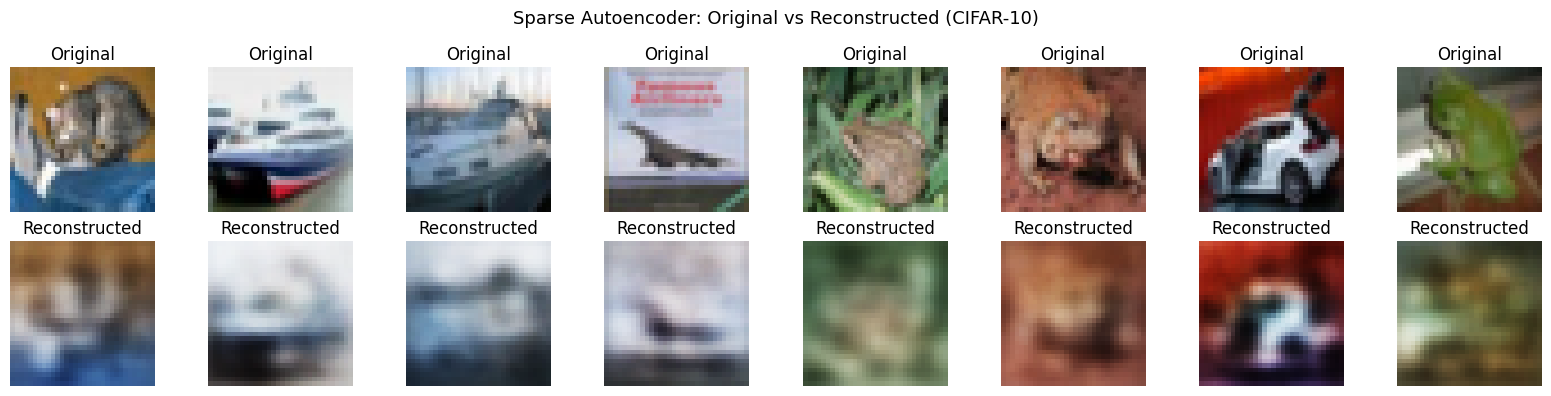

Saved: reconstruction.png


In [26]:
#plot
orig  = denormalize(sample_images.cpu()).view(-1, 3, 32, 32)
recon = denormalize(reconstructed.cpu()).view(-1, 3, 32, 32)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(orig[i].permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")

    axes[1, i].imshow(recon[i].permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
    axes[1, i].set_title("Reconstructed")

plt.suptitle("Sparse Autoencoder: Original vs Reconstructed (CIFAR-10)", fontsize=13)
plt.tight_layout()
plt.savefig("reconstruction.png", dpi=150)
plt.show()
print("Saved: reconstruction.png")

In [27]:
results = []

for beta in [0.0, 1e-4, 1e-3, 1e-2]:
    exp_model     = SparseAutoencoder().to(device)
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=1e-3)

    for _ in range(3):
        train(exp_model, train_loader, exp_optimizer, beta=beta)

    test_loss = evaluate(exp_model, test_loader)
    results.append((beta, test_loss))
    print(f"Beta: {beta:.4f} | Test Reconstruction Loss: {test_loss:.4f}")

print("\nDone.")

Beta: 0.0000 | Test Reconstruction Loss: 0.0361
Beta: 0.0001 | Test Reconstruction Loss: 0.0382
Beta: 0.0010 | Test Reconstruction Loss: 0.0512
Beta: 0.0100 | Test Reconstruction Loss: 0.0648

Done.


## Beta Experiment — Observations
- Beta = 0.0 (no sparsity) gives the best reconstruction loss (0.0361) —
  the model uses all neurons freely.
- As beta increases, reconstruction loss increases, reducing the model's ability to reconstruct fine details.